In [1]:
import tensorflow as tf
print(tf.__version__)
print(tf.keras)

2.13.0
<module 'keras.api._v2.keras' from 'C:\\Users\\ADMIN\\anaconda3\\envs\\aimlcourse\\lib\\site-packages\\keras\\api\\_v2\\keras\\__init__.py'>


In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import layers


In [20]:
# Basic Libraries
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import pydot
import seaborn as sns

#Evaluation library
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV


# Deep Learning libraries (TensorFlow 2.13 compatible)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Dropout
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical


In [4]:
#Digit MNIST dataset
(X_train_digit, y_train_digit), (X_test_digit, y_test_digit) = mnist.load_data()

11490434/11490434 [==============================] - 9s 1us/step


In [5]:
X_train_digit[1]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  51, 159, 253, 159,  50,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  48, 238, 252, 252, 252, 237,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  

In [7]:
y_train_digit

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

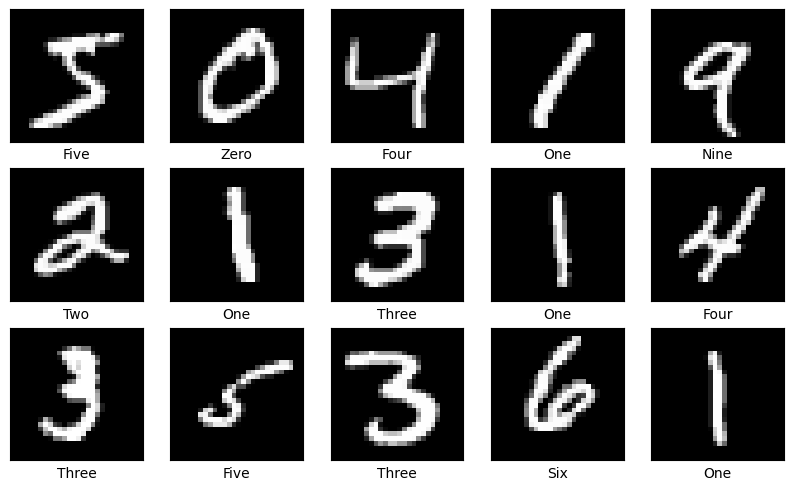

In [11]:
#Names of numbers in the dataset in order
col_names = ['Zero','One','Two','Three','Four','Five','Six','Seven','Eight','Nine']

#Visualizing the digits
plt.figure(figsize=(10,10))
for i in range(15):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(X_train_digit[i], cmap='gray')
    plt.xlabel(col_names[y_train_digit[i]])
plt.show()

In [12]:
X_train_digit.shape

(60000, 28, 28)

In [13]:
#As it is in 3d we need to change the input to 2D for ANN

X_train_digit = X_train_digit.reshape(60000, 784)
X_test_digit = X_test_digit.reshape(10000, 784)

In [14]:
X_train_digit.shape

(60000, 784)

In [15]:
y_test_digit.shape

(10000,)

In [16]:
#Here we are encoding the output as the output should be in one hot label encoding

#Encoding Digit MNIST Labels
y_train_digit = to_categorical(y_train_digit, num_classes=10)

y_test_digit = to_categorical(y_test_digit, num_classes=10)

In [17]:
y_train_digit[1]

array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32)

In [24]:
#Creating base neural network
model = tf.keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(784,)),
    #layers.Dropout(0.3),
    #layers.BatchNormalization(),
    layers.Dense(64, activation='relu'),
    #layers.Dropout(0.3),
    #layers.BatchNormalization(),
    layers.Dense(64, activation='relu'),
    #layers.Dropout(0.3),
    #layers.BatchNormalization(),
    layers.Dense(10,activation='sigmoid'),
])

In [25]:
#param_number = output_channel_number * (input_channel_number + 1)
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               200960    
                                                                 
 dense_1 (Dense)             (None, 64)                16448     
                                                                 
 dense_2 (Dense)             (None, 64)                4160      
                                                                 
 dense_3 (Dense)             (None, 10)                650       
                                                                 
Total params: 222218 (868.04 KB)
Trainable params: 222218 (868.04 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [26]:
#Compiling the model
model.compile(loss="categorical_crossentropy",
              optimizer="adam",
              metrics = ['accuracy'])

In [27]:
history=model.fit(X_train_digit, y_train_digit, batch_size=100, epochs=10,validation_data=(X_test_digit, y_test_digit))

Epoch 1/10
600/600 [==============================] - 13s 12ms/step - loss: 1.4731 - accuracy: 0.8278 - val_loss: 0.4016 - val_accuracy: 0.8959
Epoch 2/10
600/600 [==============================] - 7s 12ms/step - loss: 0.2960 - accuracy: 0.9226 - val_loss: 0.2666 - val_accuracy: 0.9313
Epoch 3/10
600/600 [==============================] - 7s 12ms/step - loss: 0.2083 - accuracy: 0.9443 - val_loss: 0.2429 - val_accuracy: 0.9421
Epoch 4/10
600/600 [==============================] - 6s 10ms/step - loss: 0.1654 - accuracy: 0.9559 - val_loss: 0.2016 - val_accuracy: 0.9492
Epoch 5/10
600/600 [==============================] - 5s 9ms/step - loss: 0.1386 - accuracy: 0.9621 - val_loss: 0.1878 - val_accuracy: 0.9548
Epoch 6/10
600/600 [==============================] - 6s 10ms/step - loss: 0.1254 - accuracy: 0.9655 - val_loss: 0.1720 - val_accuracy: 0.9592
Epoch 7/10
600/600 [==============================] - 5s 9ms/step - loss: 0.1024 - accuracy: 0.9710 - val_loss: 0.1734 - val_accuracy: 0.9584


In [28]:
#Predicting the labels-DIGIT
y_predict = model.predict(X_test_digit)

313/313 [==============================] - 4s 6ms/step


In [29]:
y_predict[0]

array([5.2744897e-05, 9.9300039e-01, 9.9998045e-01, 9.9941391e-01,
       8.1983733e-01, 3.4106916e-01, 1.4151917e-08, 1.0000000e+00,
       8.8823476e-04, 9.8252487e-01], dtype=float32)

In [30]:
y_predicts=np.argmax(y_predict, axis=1) # Here we get the index of maximum value in the encoded vector


In [31]:
y_predicts

array([7, 2, 1, ..., 4, 3, 6], dtype=int64)

In [32]:
y_test_digit_eval=np.argmax(y_test_digit, axis=1)

In [33]:
y_test_digit_eval

array([7, 2, 1, ..., 4, 5, 6], dtype=int64)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10452\1537462102.py:3: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-deep')


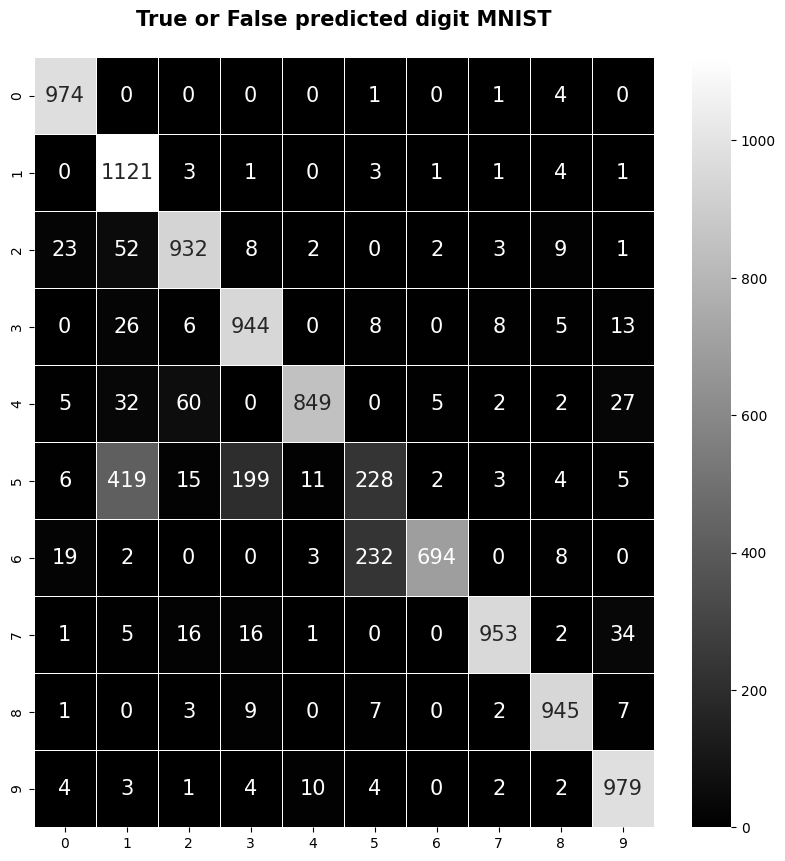

In [34]:
#Confusion matrix for Digit MNIST
con_mat=confusion_matrix(y_test_digit_eval,y_predicts)
plt.style.use('seaborn-deep')
plt.figure(figsize=(10,10))
sns.heatmap(con_mat,annot=True,annot_kws={'size': 15},linewidths=0.5,fmt="d",cmap="gray")
plt.title('True or False predicted digit MNIST\n',fontweight='bold',fontsize=15)
plt.show()

In [35]:
from sklearn.metrics import classification_report

print(classification_report(y_test_digit_eval,y_predicts))

              precision    recall  f1-score   support

           0       0.94      0.99      0.97       980
           1       0.68      0.99      0.80      1135
           2       0.90      0.90      0.90      1032
           3       0.80      0.93      0.86      1010
           4       0.97      0.86      0.91       982
           5       0.47      0.26      0.33       892
           6       0.99      0.72      0.84       958
           7       0.98      0.93      0.95      1028
           8       0.96      0.97      0.96       974
           9       0.92      0.97      0.94      1009

    accuracy                           0.86     10000
   macro avg       0.86      0.85      0.85     10000
weighted avg       0.86      0.86      0.85     10000



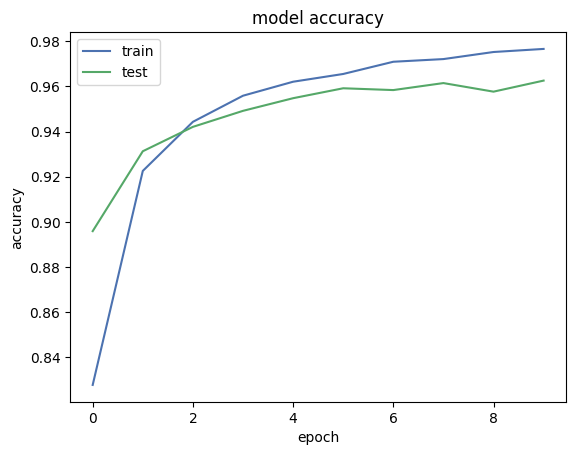

In [36]:
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='best')
plt.show()


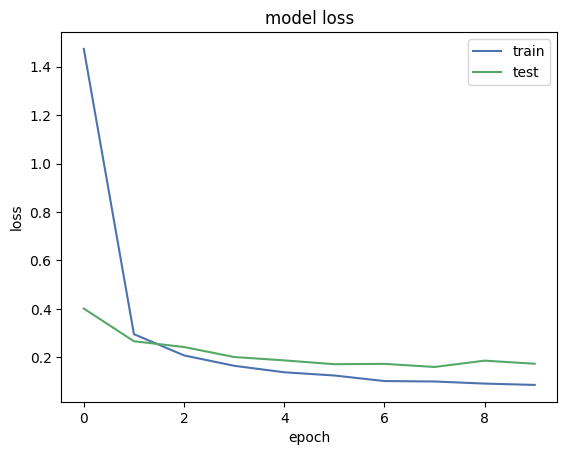

In [37]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='best')
plt.show()

In [38]:
#tf.expand_dims(X_test_digit[0])
y_predict_single = model.predict(X_test_digit[[2]])
y_predicts_single=np.argmax(y_predict_single, axis=1) # Here we get the index of maximum value in the encoded vector
y_test_digit_eval=np.argmax(y_test_digit, axis=1)

1/1 [==============================] - 0s 476ms/step


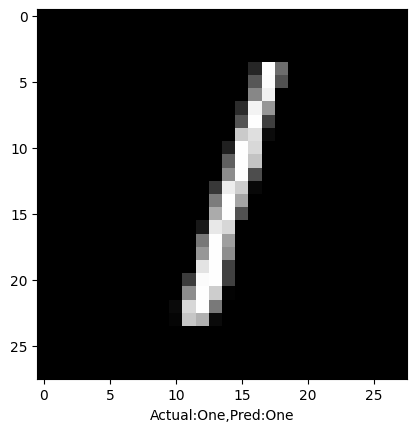

In [39]:
#Names of numbers in the dataset in order
col_names = ['Zero','One','Two','Three','Four','Five','Six','Seven','Eight','Nine']

#Visualizing the digits
#plt.figure(figsize=(10,10))
plt.imshow(X_test_digit[2].reshape(28,28), cmap='gray')
plt.xlabel("Actual:{},Pred:{}".format(col_names[np.argmax(y_test_digit[2])],col_names[y_predicts_single[0]]))
plt.show()